In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

In [14]:
pip install seaborn --upgrade

^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Load the dataset
#df = pd.read_csv("DiabetesDataSets/diabetes_012_health_indicators_BRFSS2015.csv")
df = pd.read_csv("DiabetesDataSets/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
#df = pd.read_csv("DiabetesDataSets/diabetes_binary_health_indicators_BRFSS2015.csv")
#Display the first few rows
print(df.head())

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1              0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2              0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3              0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4              0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      3.0       5.0      30.0       0.0  1.0   4.0   

In [3]:
#Gather the date
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

# X = df.drop("Diabetes_012", axis=1)
# y = df["Diabetes_012"]

In [4]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
lr_model = LogisticRegression(max_iter = 1500)
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1500
,multi_class,'deprecated'


In [7]:
y_pred = lr_model.predict(X_test_scaled)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7458094631869298


In [9]:
print(classification_report(y_test, y_pred))
#Recall (Finding patients who actually have diabetes)
#Precision (Avoiding too many false alarms)


              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7070
         1.0       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



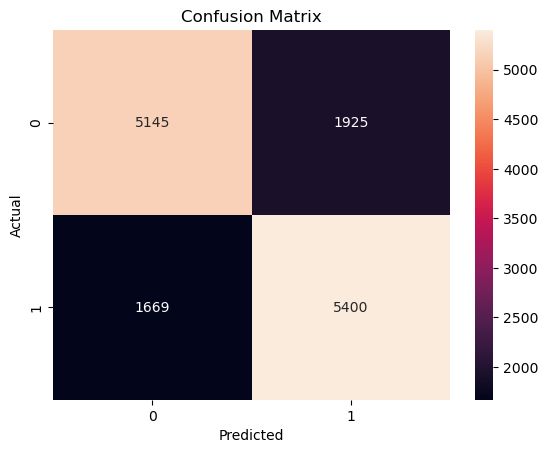

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

importance.sort_values(
    by="Coefficient",
    ascending=False,
    inplace=True
)

print(importance)

                 Feature  Coefficient
13               GenHlth     0.661160
3                    BMI     0.540853
18                   Age     0.430527
0                 HighBP     0.361950
1               HighChol     0.294858
2              CholCheck     0.207603
17                   Sex     0.135184
6   HeartDiseaseorAttack     0.093864
16              DiffWalk     0.045081
5                 Stroke     0.044522
11         AnyHealthcare     0.008592
12           NoDocbcCost     0.005561
4                 Smoker    -0.002305
8                 Fruits    -0.010585
9                Veggies    -0.018659
7           PhysActivity    -0.020754
19             Education    -0.031015
14              MentHlth    -0.032859
15              PhysHlth    -0.082578
20                Income    -0.122171
10     HvyAlcoholConsump    -0.150917


In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
rf_pred = rf_model.predict(X_test)

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

         0.0       0.75      0.70      0.72      7070
         1.0       0.72      0.77      0.74      7069

    accuracy                           0.73     14139
   macro avg       0.73      0.73      0.73     14139
weighted avg       0.73      0.73      0.73     14139



In [14]:
accuracy = accuracy_score(y_test, rf_pred)
print(accuracy)

0.7335738029563619


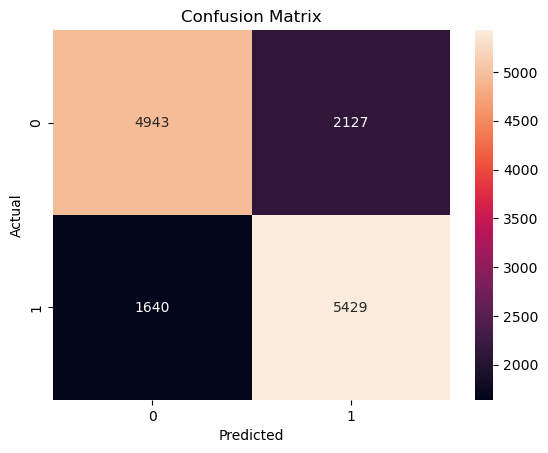

In [15]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

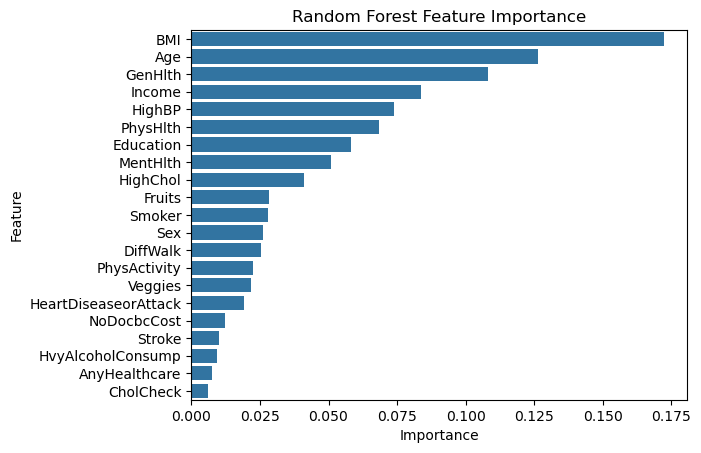

In [17]:
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [18]:
risk_scores = rf_model.predict_proba(X_test)[:,1]

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.7513659097764898


In [23]:
rf_best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

rf_best_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
rf_best_pred = rf_best_model.predict(X_test)

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

         0.0       0.75      0.70      0.72      7070
         1.0       0.72      0.77      0.74      7069

    accuracy                           0.73     14139
   macro avg       0.73      0.73      0.73     14139
weighted avg       0.73      0.73      0.73     14139



In [26]:
accuracy = accuracy_score(y_test, rf_best_pred)
print(accuracy)

0.7494872338920716


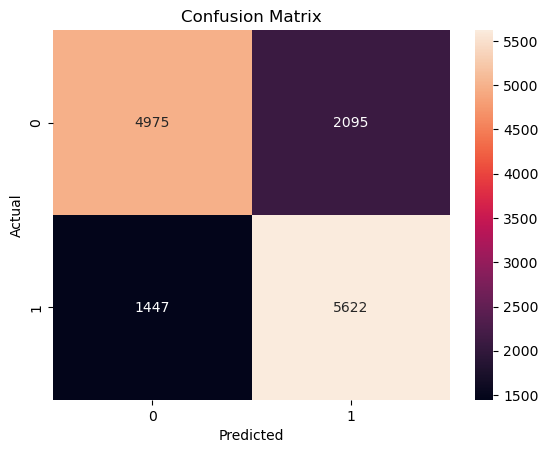

In [27]:
cm = confusion_matrix(y_test, rf_best_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Risk Analysis

In [31]:
risk_scores = rf_model.predict_proba(X_test)[:,1]
risk_scores

array([0.88, 0.72, 0.33, ..., 0.86, 0.9 , 0.05])

In [32]:
results = X_test.copy()
results["RiskScore"] = risk_scores

results["RiskGroup"] = pd.cut(
    results["RiskScore"],
    bins=[0,0.3,0.7,1],
    include_lowest=True,
    labels=["Low", "Medium", "High"]
)

In [33]:
results["RiskGroup"]

57608      High
18474      High
47268    Medium
31419       Low
56545    Medium
          ...  
14537    Medium
13704       Low
62461      High
70180      High
25373       Low
Name: RiskGroup, Length: 14139, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [34]:
results["RiskGroup"].value_counts()
#Low = (41826) 82.4%
#Medium = (8560) 16.9%
#High= (350) 0.7%

RiskGroup
Medium    5551
High      4418
Low       4170
Name: count, dtype: int64

In [35]:
high_risk = results[
    results["RiskGroup"] == "High"
]

In [36]:
high_risk.mean(numeric_only=True)
#Age 9 = 60 to 64 | Age 10 = 65 to 79 
#Edu 4 = College 1 year to 3 years| Edu 5 = College 4 years or more
#Income 5 = $25,000 to less than $35,000| 6 = $35,000 to less than $50,000

HighBP                   0.908330
HighChol                 0.798551
CholCheck                0.997963
BMI                     33.998868
Smoker                   0.540063
Stroke                   0.125396
HeartDiseaseorAttack     0.309190
PhysActivity             0.558171
Fruits                   0.571526
Veggies                  0.745586
HvyAlcoholConsump        0.009507
AnyHealthcare            0.966727
NoDocbcCost              0.115211
GenHlth                  3.668402
MentHlth                 5.197827
PhysHlth                10.351517
DiffWalk                 0.510638
Sex                      0.468085
Age                      9.697827
Education                4.623133
Income                   4.784518
RiskScore                0.821784
dtype: float64

In [37]:
low_risk = results[
    results["RiskGroup"] == "Low"
]

In [38]:
low_risk.mean(numeric_only=True)
#Tend to have lower BP and Chol
#PhysHealth and diffWalk lower
#YoungerAverage age (down 2 tiers)

HighBP                   0.157074
HighChol                 0.233813
CholCheck                0.936451
BMI                     25.984173
Smoker                   0.366906
Stroke                   0.004317
HeartDiseaseorAttack     0.011990
PhysActivity             0.854916
Fruits                   0.661391
Veggies                  0.855635
HvyAlcoholConsump        0.078897
AnyHealthcare            0.947002
NoDocbcCost              0.070024
GenHlth                  1.910072
MentHlth                 2.453717
PhysHlth                 1.631415
DiffWalk                 0.025180
Sex                      0.404556
Age                      6.711990
Education                5.303837
Income                   6.672662
RiskScore                0.120235
dtype: float64

In [80]:
feature_importance

,Feature,Importance
3,BMI,0.184123
18,Age,0.122429
20,Income,0.098747
15,PhysHlth,0.084610
19,Education,0.070320
13,GenHlth,0.070139
14,MentHlth,0.064511
0,HighBP,0.042603
8,Fruits,0.033205
4,Smoker,0.033193


In [40]:
risk_compare = pd.DataFrame({
    'Low_risk': low_risk.mean(numeric_only=True),
    'High_risk':high_risk.mean(numeric_only=True)
})
risk_compare

,Low_risk,High_risk
HighBP,0.157074,0.908330
HighChol,0.233813,0.798551
CholCheck,0.936451,0.997963
BMI,25.984173,33.998868
Smoker,0.366906,0.540063
Stroke,0.004317,0.125396
HeartDiseaseorAttack,0.011990,0.309190
PhysActivity,0.854916,0.558171
Fruits,0.661391,0.571526
Veggies,0.855635,0.745586


Based on the findings, High-risk patients exhibited a substantially higher difficulty with walking and a higher number of days where their physical health was not good and where. This suggest that a lack of movement and excercise is strongly associated with a greater diabetes risk. 

In [111]:
feature_importance

,Feature,Importance
3,BMI,0.184123
18,Age,0.122429
20,Income,0.098747
15,PhysHlth,0.084610
19,Education,0.070320
13,GenHlth,0.070139
14,MentHlth,0.064511
0,HighBP,0.042603
8,Fruits,0.033205
4,Smoker,0.033193
